In [1]:
## conda activate gpy_torch_env
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import tqdm
import torch 
from torch.autograd.functional import jacobian
from torch.distributions.multivariate_normal import MultivariateNormal
import gpytorch
import pyro
from pyro.infer import MCMC, NUTS
import pyro.distributions as dist
from scipy.linalg import eigh
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.stats import norm, multivariate_normal, invgamma, uniform
from scipy import interpolate
import pickle



torch.Size([72, 200])
torch.Size([72, 200])


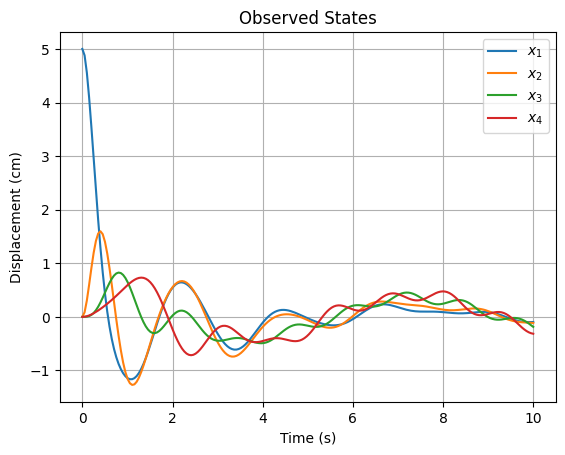

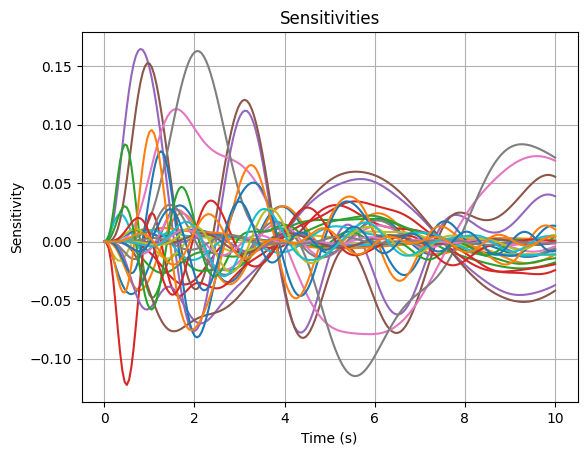

In [21]:
## Spring Problem
num_par = 8 #leave off discrepancy hyperparameters
J = 4
burnin = 5000
from Four_Spring_Model import call_model as call_model_4spring
from Run_FourSpring_AMwithGibbs_50signals import compute_jacobian as jac_4spring




for i in [10]:
    if i<10:
        # fname = 'Fitz_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        fname = 'FourSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        # fname = 'Fitz_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        fname = 'FourSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    F_true = data['force_true']
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']
    
    states = call_model_4spring(data_generating_par[0:num_par],tvals,F_true)
    print(np.shape(states))
    (x1,x2,x3,x4,v1,v2,v3,v4,
    x1k1,x2k1,x3k1,x4k1,v1k1,v2k1,v3k1,v4k1,
    x1c1,x2c1,x3c1,x4c1,v1c1,v2c1,v3c1,v4c1,
    x1k2,x2k2,x3k2,x4k2,v1k2,v2k2,v3k2,v4k2,
    x1c2,x2c2,x3c2,x4c2,v1c2,v2c2,v3c2,v4c2,
    x1k3,x2k3,x3k3,x4k3,v1k3,v2k3,v3k3,v4k3,
    x1c3,x2c3,x3c3,x4c3,v1c3,v2c3,v3c3,v4c3,
    x1k4,x2k4,x3k4,x4k4,v1k4,v2k4,v3k4,v4k4,
    x1c4,x2c4,x3c4,x4c4,v1c4,v2c4,v3c4,v4c4) = states

    state_sens = np.array((x1k1,x2k1,x3k1,x4k1,
             x1c1,x2c1,x3c1,x4c1,
             x1k2,x2k2,x3k2,x4k2,
             x1c2,x2c2,x3c2,x4c2,
             x1k3,x2k3,x3k3,x4k3,
             x1c3,x2c3,x3c3,x4c3,
             x1k4,x2k4,x3k4,x4k4,
             x1c4,x2c4,x3c4,x4c4))
    print(np.shape(states))
    plt.figure()
    plt.plot(tvals,states[0:J].T)
    plt.title('Observed States')
    plt.legend((f'$x_1$',f'$x_2$',f'$x_3$',f'$x_4$'))
    plt.ylabel('Displacement (cm)')
    plt.xlabel('Time (s)')
    plt.grid()

    plt.figure()
    plt.plot(tvals,state_sens.T)
    plt.title('Sensitivities')
    plt.ylabel('Sensitivity')
    plt.xlabel('Time (s)')
    plt.grid()
    


    ###############################
    



torch.Size([20, 200])
torch.Size([20, 200])


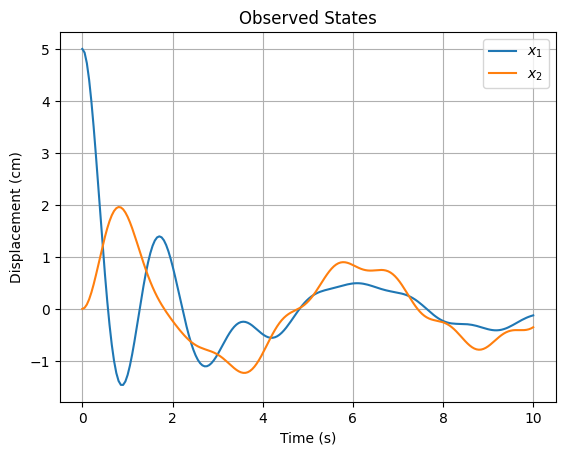

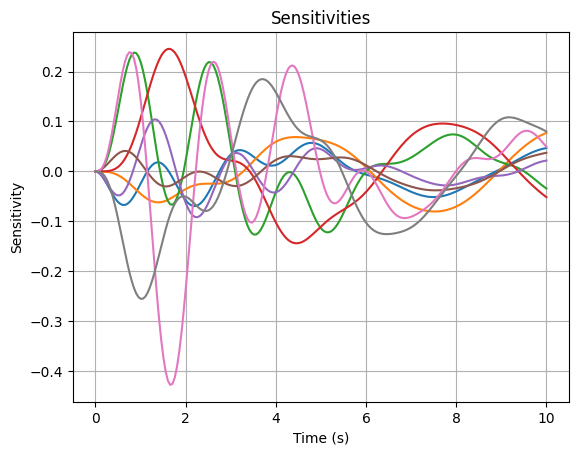

In [23]:
## Spring Problem
num_par = 4 #leave off discrepancy hyperparameters
J = 2
burnin = 5000
from Run_TwoSpring_AMwithGibbs_50signals import call_model as call_model_2spring
from Run_TwoSpring_AMwithGibbs_50signals import compute_jacobian as jac_2spring



for i in [12]:
    if i<10:
        # fname = 'Fitz_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        fname = 'TwoSpring_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        # fname = 'Fitz_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        fname = 'TwoSpring_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    F_true = data['force_true']
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']

    states = call_model_2spring(data_generating_par[0:num_par],tvals,F_true)
    print(np.shape(states))
    (x1, x2, v1, v2,
         x1k1, x2k1, v1k1, v2k1,
         x1c1, x2c1, v1c1, v2c1,
         x1k2, x2k2, v1k2, v2k2,
         x1c2, x2c2, v1c2, v2c2)  = states

    state_sens = np.array((x1k1,x2k1,
                x1c1,x2c1,
                x1k2,x2k2,
                x1c2,x2c2))
    print(np.shape(states))
    plt.figure()
    plt.plot(tvals,states[0:J].T)
    plt.title('Observed States')
    plt.legend((f'$x_1$',f'$x_2$'))
    plt.ylabel('Displacement (cm)')
    plt.xlabel('Time (s)')
    plt.grid()

    plt.figure()
    plt.plot(tvals,state_sens.T)
    plt.title('Sensitivities')
    plt.ylabel('Sensitivity')
    plt.xlabel('Time (s)')
    plt.grid()
        

    




(4, 50)


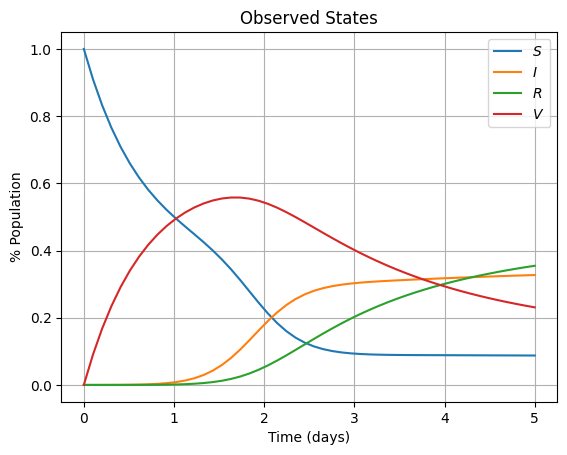

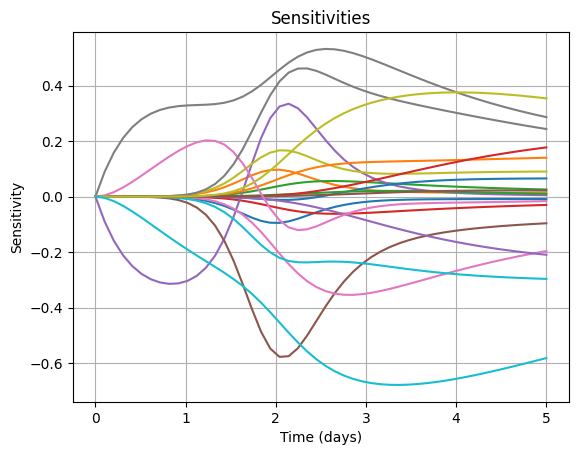

In [25]:
## Spring Problem
num_par = 5 #leave off discrepancy hyperparameters
J = 3
burnin = 5000
from Run_SIRV_IRV_AMwithGibbs_50signals import call_model as call_model_IRV
from Run_SIRV_IRV_AMwithGibbs_50signals import compute_jacobian as jac_IRV



# Helper function since IRV model gives back all four states, we just need the last three
def IRV_only(params,x):
    all_out = call_model_IRV(params,x)
    return all_out[0:4,:]



for i in [7]:
    if i<10:
        # fname = 'Fitz_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        fname = 'SIRV_IRV_50signal_results_V2/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        # fname = 'Fitz_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        fname = 'SIRV_IRV_50signal_results_V2/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']

    S,I,R,V,Sa,Ia,Ra,Va,Sv,Iv,Rv,Vv,Smu,Imu,Rmu,Vmu,Swr,Iwr,Rwr,Vwr,Swv,Iwv,Rwv,Vwv = call_model_IRV(data_generating_par[0:num_par],tvals)
    states = np.array((S,I,R,V))
    state_sens = np.array((Sa,Ia,Ra,Va,
                           Sv,Iv,Rv,Vv,
                           Smu,Imu,Rmu,Vmu,
                           Swr,Iwr,Rwr,Vwr,
                           Swv,Iwv,Rwv,Vwv))
    print(np.shape(states))
    plt.figure()
    plt.plot(tvals,states.T)
    plt.title('Observed States')
    plt.legend((f'$S$',f'$I$',f'$R$',f'$V$'))
    plt.ylabel('% Population')
    plt.xlabel('Time (days)')
    plt.grid()

    plt.figure()
    plt.plot(tvals,state_sens.T)
    plt.title('Sensitivities')
    plt.ylabel('Sensitivity')
    plt.xlabel('Time (days)')
    plt.grid()


    




(2, 100)


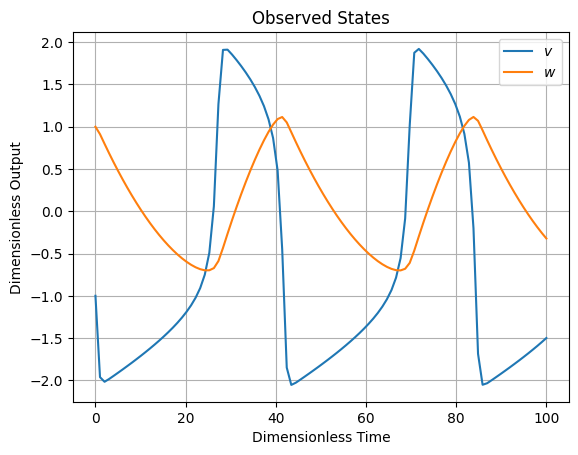

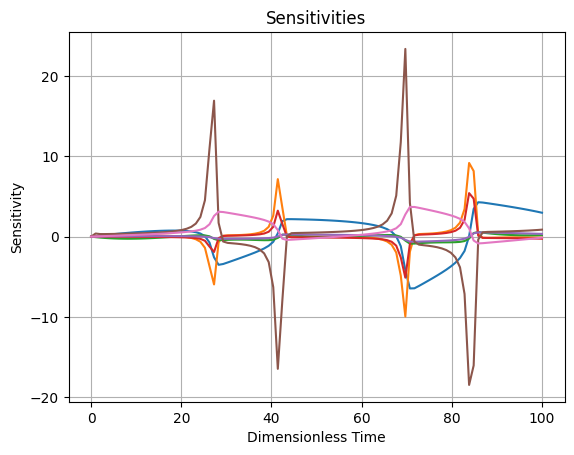

In [38]:
## Spring Problem
num_par = 4 #leave off discrepancy hyperparameters
J = 2
burnin = 5000
from Run_Fitz_AMwithGibbs_50signals import call_model as call_model_Fitz
from Run_Fitz_AMwithGibbs_50signals import compute_jacobian as jac_Fitz

marg_kernel = gpytorch.kernels.RBFKernel()
marg_kernel.raw_lengthscale.requires_grad = False
target_min_eigval = 1e-6
min_jitter = 1e-10 
gamma_true=1.0

GP_Cov_unc = gpytorch.kernels.MultitaskKernel(marg_kernel, num_tasks=J) ## eval -> nJ x nJ (need to reshape)
GP_Cov_unc.data_covar_module.initialize(lengthscale=torch.tensor(0.1))
GP_Cov_unc.data_covar_module.raw_lengthscale.requires_grad = False

# Helper function since IRV model gives back all four states, we just need the last three


for i in [69]:
    if i<10:
        fname = 'Fitz_100signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_00'+f'{i}' + '_results.pkl'
    else:
        fname = 'Fitz_100signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'FourSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'TwoSpring_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IRV_50signal_results/signal_0'+f'{i}' + '_results.pkl'
        # fname = 'SIRV_IV_50signal_results/signal_0'+f'{i}' + '_results.pkl'

    

    with open(fname, 'rb') as f:
        data = pickle.load(f)

    chain_IND_all = data['chain_IND_all']
    chain_MOP_all = data['chain_MOP_all']
    s2chain_IND_all = data['s2chain_IND_all']
    s2chain_MOP_all = data['s2chain_MOP_all']
    tvals = torch.tensor(data['tvals'])
    n_grid = len(tvals)
    t_obs = data['t_obs']
    xi_true = data['xi_true']
    y_obs = data['obs']

    l2_par = data['x_sorted'][0,:]
    data_generating_par = data['theta_all_true']

    

    v,w,va,wa,vb,wb,vtau,wtau,vI,wI = call_model_Fitz(data_generating_par[0:num_par],tvals)
    states = np.array((v,w))
    state_sens = np.array((wa,vb,wb,vtau,wtau,vI,wI))
    print(np.shape(states))
    plt.figure()
    plt.plot(tvals,states.T)
    plt.title('Observed States')
    plt.legend((f'$v$',f'$w$'))
    plt.ylabel('Dimensionless Output')
    plt.xlabel('Dimensionless Time')
    plt.grid()

    plt.figure()
    plt.plot(tvals,state_sens.T)
    plt.title('Sensitivities')
    plt.ylabel('Sensitivity')
    plt.xlabel('Dimensionless Time')
    plt.grid()






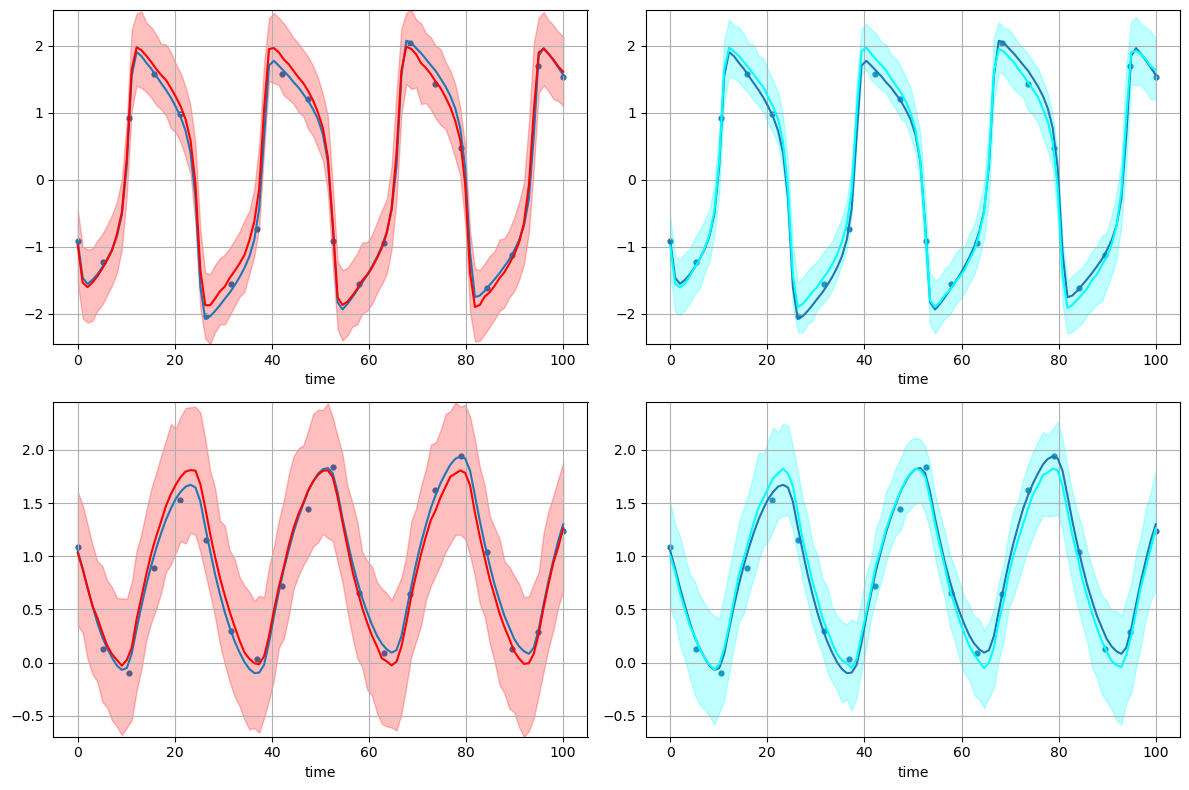

In [39]:
###############################
# Plot is without discrepancy added
plt.figure(figsize=(12, 8))
for iii in range(J):
    y_upper = np.max((np.max(x_upper_IND_disc[iii,:].detach().numpy().flatten()),np.max(x_upper_MOP_disc[iii,:].detach().numpy().flatten())))
    y_lower = np.min((np.min(x_lower_IND_disc[iii,:].detach().numpy().flatten()),np.min(x_lower_MOP_disc[iii,:].detach().numpy().flatten())))
    
    plt.subplot(J,2,(iii)*2+1)
    plt.scatter(t_obs, y_obs[:,iii], s=12, label="observations")
    plt.plot(tvals.numpy(), xi_true[:,iii], label="true sig + disc")
    plt.plot(tvals.numpy(), x_mean_IND_disc[iii,:], label="IND mean",color='red')
    # plt.plot(tvals.numpy(), x_true[0,:],color='black')
    plt.fill_between(
        tvals.numpy(),
        x_lower_IND_disc[iii,:].detach().numpy(),
        x_upper_IND_disc[iii,:].detach().numpy(),
        alpha=0.25,
        color='red',
        label="90% posterior band",
    )
    plt.xlabel("time")
    # plt.ylabel("displacement")
    # plt.legend()
    plt.ylim((y_lower,y_upper))
    plt.tight_layout()
    plt.grid()

    plt.subplot(J,2,(iii)*2+2)
    plt.scatter(t_obs, y_obs[:,iii], s=12, label="observations")
    plt.plot(tvals.numpy(), xi_true[:,iii], label="true sig + disc")
    plt.plot(tvals.numpy(), x_mean_MOP_disc[iii,:], label="MOP mean",color='cyan')
    # plt.plot(tvals.numpy(), x_true[0,:],color='black')
    plt.fill_between(
        tvals.numpy(),
        x_lower_MOP_disc[iii,:].detach().numpy(),
        x_upper_MOP_disc[iii,:].detach().numpy(),
        alpha=0.25,
        color='cyan',
        label="90% posterior band",
    )
    plt.xlabel("time")
    # plt.ylabel("displacement")
    # plt.legend()
    plt.ylim((y_lower,y_upper))
    plt.grid()
    plt.tight_layout()
plt.show()

In [ ]:
for i in range(J):
    # For forward model evals WITHOUT DISCREPANCY INCLUDED
    IND_metrics = time_dependent_prediction_metrics(
        posterior_state_IND[:,i,:],
        xi_true[:,i],
        credibility_level=0.95
    )

    MOP_metrics = time_dependent_prediction_metrics(
        posterior_state_MOP[:,i,:],
        xi_true[:,i],
        credibility_level=0.95
    )
    # For model evals WITH DISCREPANCY ADDED TO OUTPUT
    # IND_metrics = time_dependent_prediction_metrics(
    #     posterior_state_IND_disc[:,i,:],
    #     xi_true[:,i],
    #     credibility_level=0.95
    # )

    # MOP_metrics = time_dependent_prediction_metrics(
    #     posterior_state_MOP_disc[:,i,:],
    #     xi_true[:,i],
    #     credibility_level=0.95
    # )
    print(f"OUTPUT {i}\n")
    print("Mean RMSE over time:", IND_metrics["mean_rmse_over_time"],MOP_metrics["mean_rmse_over_time"])
    print("Mean bias over time:", IND_metrics["mean_bias_over_time"], MOP_metrics["mean_bias_over_time"])
    print("Mean coverage over time:", IND_metrics["mean_coverage_over_time"], MOP_metrics["mean_coverage_over_time"])
    print("Mean interval width over time:", IND_metrics["mean_interval_width_over_time"], MOP_metrics["mean_interval_width_over_time"])

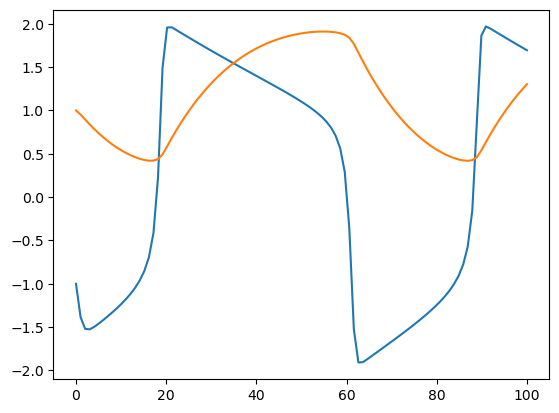

In [81]:
np.set_printoptions(precision=3, suppress=True)

states = call_model_Fitz([1.0,1.0,25,1.2],tvals)
plt.figure()
plt.plot(tvals,states[0:2,:].T)
# plt.plot(tvals,states[:,1])
plt.show()
# print(f"{data_generating_par[:-2]}")